# Rotation-theory comparison for BaMgF4

This notebook compares two implemented rotation Maker-fringe models using mock metadata for the six BaMgF4 $d_{ij}$ measurement geometries. It does not load an experiment folder.

The curves are normalized independently so that the comparison emphasizes fringe positions and shape rather than each theory's absolute prefactor. Phase is compared when both strategies expose `aux["Psi"]`. Minima positions are always compared because they remain a common observable even when a model does not have a simple `envelope * sin^2(Psi)` decomposition.

In [22]:
import copy
import sys
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import find_peaks

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "test_codes":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from fitting_strategies.bechthold1977 import Bechthold1977Strategy
from fitting_strategies.braun1997 import Braun1997Strategy
from fitting_strategies.jerphagnon1970 import Jerphagnon1970Strategy
from fitting_strategies.shoji1997 import Shoji1997RotationStrategy

%matplotlib inline

## Available geometries and theories

`Dou1989Strategy` is not listed because its rotation `_maker_fringes` implementation is incomplete. `Ishidate1974Strategy` currently inherits the Jerphagnon curve unchanged, so listing it as a separate theory would duplicate Jerphagnon. The current Jerphagnon implementation cannot evaluate a 45-degree input polarization, while Shoji is available only for the $d_{15}$ and $d_{24}$ geometries implemented in its geometry table.

Edit only the values in the next cell to select the two theories, thickness, and scan range. All six BMF geometries are calculated in one run. A geometry is skipped only when one of the selected theories does not support it.

In [23]:
BMF_CONFIGS = {
    "d31": {
        "label": "d31",
        "d_component": "d_31",
        "crystal_orientation": "010",
        "rot/trans_axis": "100",
        "input_polarization": 0,
        "detected_polarization": 90,
    },
    "d32": {
        "label": "d32",
        "d_component": "d_32",
        "crystal_orientation": "100",
        "rot/trans_axis": "010",
        "input_polarization": 0,
        "detected_polarization": 90,
    },
    "d33 (cut 100)": {
        "label": "d33, cut 100",
        "d_component": "d_33",
        "crystal_orientation": "100",
        "rot/trans_axis": "001",
        "input_polarization": 0,
        "detected_polarization": 0,
    },
    "d33 (cut 010)": {
        "label": "d33, cut 010",
        "d_component": "d_33",
        "crystal_orientation": "010",
        "rot/trans_axis": "001",
        "input_polarization": 0,
        "detected_polarization": 0,
    },
    "d15": {
        "label": "d15",
        "d_component": "d_15",
        "crystal_orientation": "010",
        "rot/trans_axis": "100",
        "input_polarization": 45,
        "detected_polarization": 0,
    },
    "d24": {
        "label": "d24",
        "d_component": "d_24",
        "crystal_orientation": "100",
        "rot/trans_axis": "010",
        "input_polarization": 45,
        "detected_polarization": 0,
    },
}

STRATEGIES = {
    "Jerphagnon 1970": {
        "class": Jerphagnon1970Strategy,
        "configs": {"d31", "d32", "d33 (cut 100)", "d33 (cut 010)"},
    },
    "Bechthold 1977": {
        "class": Bechthold1977Strategy,
        "configs": set(BMF_CONFIGS),
    },
    "Braun 1997": {
        "class": Braun1997Strategy,
        "configs": set(BMF_CONFIGS),
    },
    "Shoji 1997": {
        "class": Shoji1997RotationStrategy,
        "configs": {"d15", "d24"},
    },
}

## Select comparison settings

In [24]:
# Edit this block to change the comparison.
settings = {
    "theory_a": "Bechthold 1977",
    "theory_b": "Braun 1997",
    "wavelength_nm": 1064.0,
    "thickness_mm": 10.0,       # Change the sample thickness here.
    "beam_diameter_um": 400.0,
    "theta_min_deg": -20.0,
    "theta_max_deg": 20.0,
    "points": 301,              # Reduce this if Braun calculation is too slow.
}

# Available theory names: Jerphagnon 1970, Bechthold 1977, Braun 1997, Shoji 1997

for key in ("theory_a", "theory_b"):
    theory_name = settings[key]
    if theory_name not in STRATEGIES:
        raise ValueError(f"Unknown theory: {theory_name}")
if settings["theory_a"] == settings["theory_b"]:
    raise ValueError("Select two different theories.")
if settings["theta_min_deg"] >= settings["theta_max_deg"]:
    raise ValueError("Angle minimum must be smaller than angle maximum.")

settings

{'theory_a': 'Bechthold 1977',
 'theory_b': 'Braun 1997',
 'wavelength_nm': 1064.0,
 'thickness_mm': 10.0,
 'beam_diameter_um': 400.0,
 'theta_min_deg': -20.0,
 'theta_max_deg': 20.0,
 'points': 301}

## Build mock metadata and calculate curves

In [25]:
def make_mock_meta(config, settings):
    return {
        "sample": f"mock_BaMgF4_{config['label']}",
        "material": "BaMgF4",
        "method": "rotation",
        "wavelength_nm": settings["wavelength_nm"],
        "input_polarization": config["input_polarization"],
        "detected_polarization": config["detected_polarization"],
        "crystal_orientation": config["crystal_orientation"],
        "rot/trans_axis": config["rot/trans_axis"],
        "thickness_info": {"t_center_mm": settings["thickness_mm"]},
        "beam_r_x": settings["beam_diameter_um"],
        "beam_r_y": settings["beam_diameter_um"],
        "d_component": config["d_component"],
        "use_raytrace": True,
        "start": settings["theta_min_deg"],
        "end": settings["theta_max_deg"],
    }


def make_mock_analysis(mock_meta, theta_deg):
    mock_data = pd.DataFrame(
        {
            "position": theta_deg,
            "position_centered": theta_deg,
            "intensity_corrected": np.ones_like(theta_deg, dtype=float),
        }
    )
    return SimpleNamespace(meta=copy.deepcopy(mock_meta), data=mock_data)


def normalize_intensity(values):
    values = np.asarray(values, dtype=float)
    finite = np.isfinite(values)
    if not finite.any():
        raise ValueError("The model returned no finite intensity values.")
    scale = np.nanmax(np.abs(values[finite]))
    if not np.isfinite(scale) or scale == 0.0:
        raise ValueError("The model intensity has zero scale.")
    return values / scale


def calculate_theory(name, mock_meta, theta_deg):
    strategy_class = STRATEGIES[name]["class"]
    strategy = strategy_class(make_mock_analysis(mock_meta, theta_deg))
    raw, aux = strategy._maker_fringes(
        override={"theta_deg": theta_deg, "use_raytrace": True},
        return_aux=True,
    )
    return {
        "name": name,
        "raw": np.asarray(raw, dtype=float),
        "normalized": normalize_intensity(raw),
        "aux": aux,
    }


theta_deg = np.linspace(
    settings["theta_min_deg"], settings["theta_max_deg"], settings["points"]
)
comparison_results = {}
skipped_configs = {}

for config_name, config in BMF_CONFIGS.items():
    unsupported = [
        theory_name
        for theory_name in (settings["theory_a"], settings["theory_b"])
        if config_name not in STRATEGIES[theory_name]["configs"]
    ]
    if unsupported:
        skipped_configs[config_name] = f"unsupported by {', '.join(unsupported)}"
        continue

    mock_meta = make_mock_meta(config, settings)
    result_a = calculate_theory(settings["theory_a"], mock_meta, theta_deg)
    result_b = calculate_theory(settings["theory_b"], mock_meta, theta_deg)
    phase_a_raw = result_a["aux"].get("Psi")
    phase_b_raw = result_b["aux"].get("Psi")

    comparison_results[config_name] = {
        "config": config,
        "mock_meta": mock_meta,
        "result_a": result_a,
        "result_b": result_b,
        "intensity_difference": result_a["normalized"] - result_b["normalized"],
        "has_direct_phase_comparison": phase_a_raw is not None and phase_b_raw is not None,
        "phase_a": (
            np.abs(np.asarray(phase_a_raw, dtype=float)) if phase_a_raw is not None else None
        ),
        "phase_b": (
            np.abs(np.asarray(phase_b_raw, dtype=float)) if phase_b_raw is not None else None
        ),
    }

print(f"calculated: {', '.join(comparison_results)}")
if skipped_configs:
    print("skipped:")
    for config_name, reason in skipped_configs.items():
        print(f"  {config_name}: {reason}")

calculated: d31, d32, d33 (cut 100), d33 (cut 010), d15, d24


## Minima comparison

Local minima are refined with a three-point parabola and paired by side and fringe order counted outward from normal incidence. This is more physically interpretable than pairing every minimum only by nearest distance, especially when two theories predict different fringe counts.

In [26]:
def refine_minimum(x, y, index):
    if index <= 0 or index >= len(x) - 1:
        return float(x[index])
    x_local = np.asarray(x[index - 1:index + 2], dtype=float)
    y_local = np.asarray(y[index - 1:index + 2], dtype=float)
    if not np.isfinite(y_local).all():
        return float(x[index])
    a, b, _ = np.polyfit(x_local, y_local, 2)
    if not np.isfinite(a) or a <= 0.0:
        return float(x[index])
    vertex = -b / (2.0 * a)
    if vertex < x_local[0] or vertex > x_local[-1]:
        return float(x[index])
    return float(vertex)


def detect_model_minima(theta_deg, intensity):
    theta_deg = np.asarray(theta_deg, dtype=float)
    intensity = np.asarray(intensity, dtype=float)
    step = float(np.nanmedian(np.diff(theta_deg)))
    distance = max(1, int(round(0.05 / abs(step))))
    indices, _ = find_peaks(-intensity, prominence=0.005, distance=distance)
    angles = np.array(
        [refine_minimum(theta_deg, intensity, index) for index in indices], dtype=float
    )
    return angles[np.isfinite(angles)]


def minima_by_side(angles):
    angles = np.asarray(angles, dtype=float)
    return {
        "negative": np.sort(angles[angles < 0.0])[::-1],
        "positive": np.sort(angles[angles >= 0.0]),
    }


def pair_minima(angles_a, angles_b, theory_a, theory_b):
    sides_a = minima_by_side(angles_a)
    sides_b = minima_by_side(angles_b)
    rows = []
    for side in ("negative", "positive"):
        count = min(len(sides_a[side]), len(sides_b[side]))
        for order in range(count):
            angle_a = sides_a[side][order]
            angle_b = sides_b[side][order]
            rows.append(
                {
                    "side": side,
                    "order_from_center": order + 1,
                    f"{theory_a} (deg)": angle_a,
                    f"{theory_b} (deg)": angle_b,
                    "A - B (deg)": angle_a - angle_b,
                }
            )
    return pd.DataFrame(rows)


for config_name, comparison in comparison_results.items():
    result_a = comparison["result_a"]
    result_b = comparison["result_b"]
    minima_a = detect_model_minima(theta_deg, result_a["normalized"])
    minima_b = detect_model_minima(theta_deg, result_b["normalized"])
    comparison["minima_a"] = minima_a
    comparison["minima_b"] = minima_b
    comparison["minima_comparison"] = pair_minima(
        minima_a, minima_b, result_a["name"], result_b["name"]
    )
    print(
        f"{config_name}: {result_a['name']} = {len(minima_a)} minima, "
        f"{result_b['name']} = {len(minima_b)} minima"
    )

d31: Bechthold 1977 = 14 minima, Braun 1997 = 13 minima
d32: Bechthold 1977 = 40 minima, Braun 1997 = 43 minima
d33 (cut 100): Bechthold 1977 = 9 minima, Braun 1997 = 44 minima
d33 (cut 010): Bechthold 1977 = 9 minima, Braun 1997 = 44 minima
d15: Bechthold 1977 = 29 minima, Braun 1997 = 37 minima
d24: Bechthold 1977 = 8 minima, Braun 1997 = 29 minima


## Comparison plots

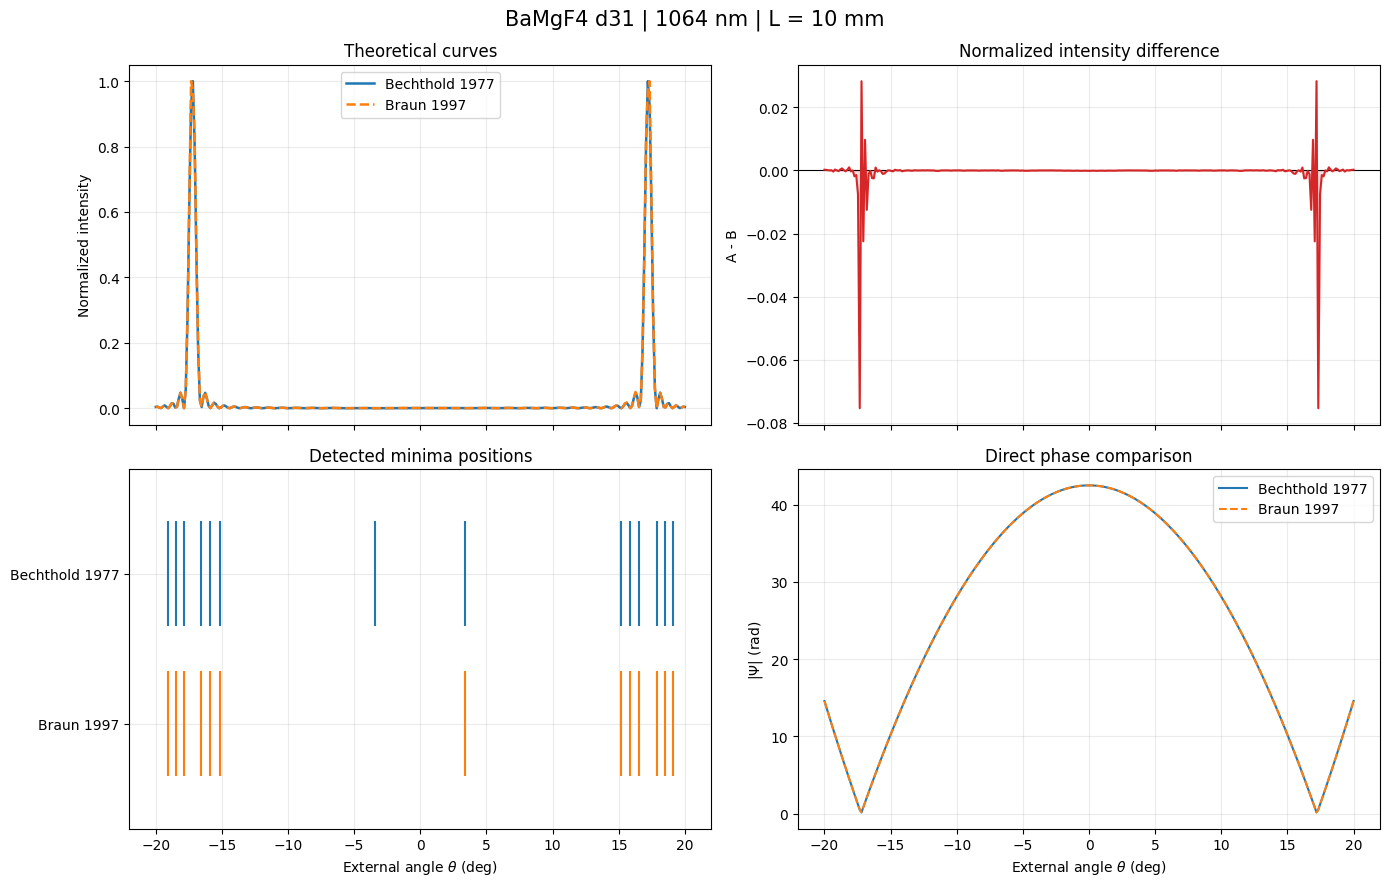

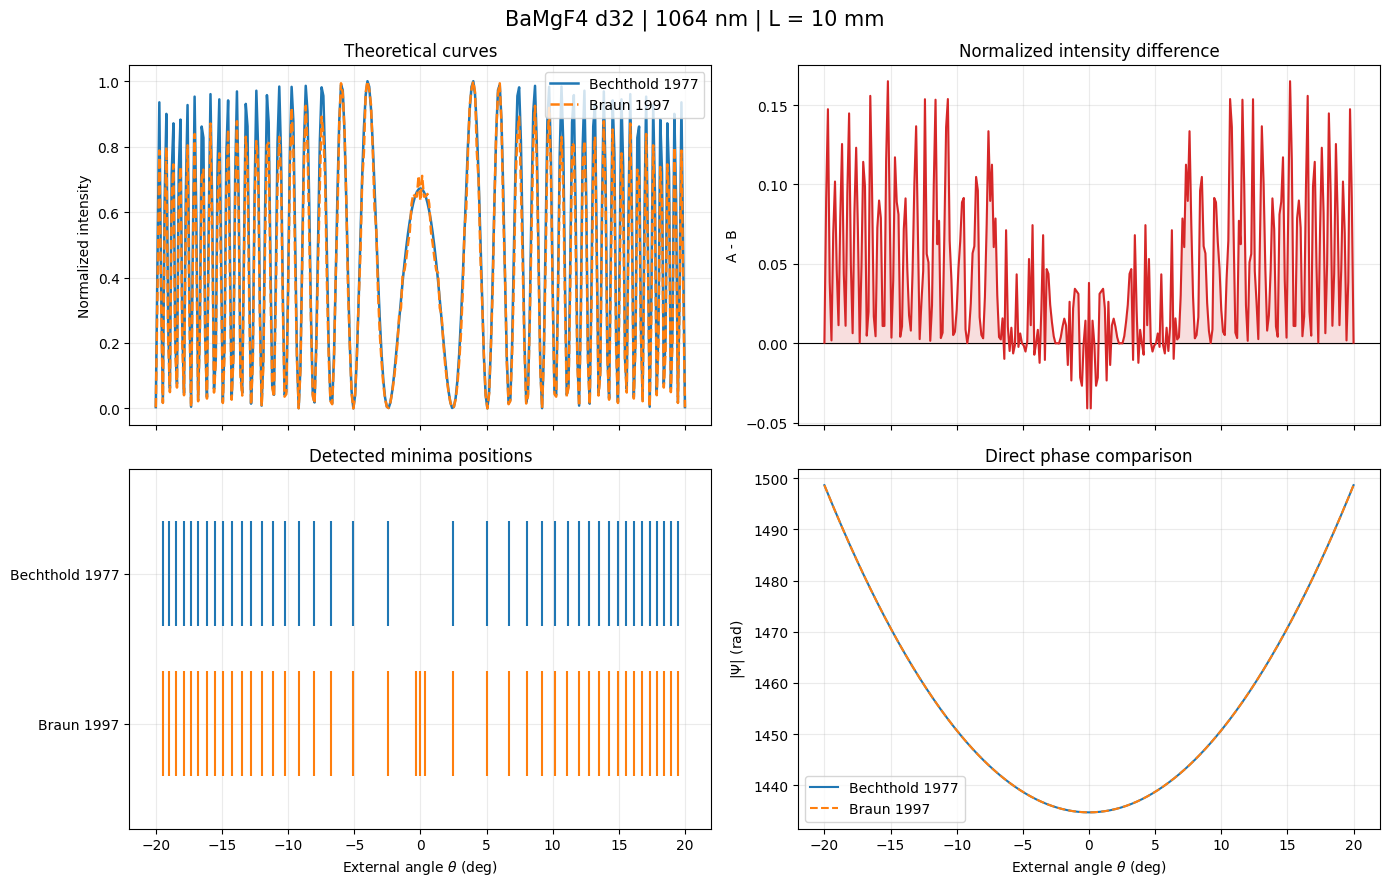

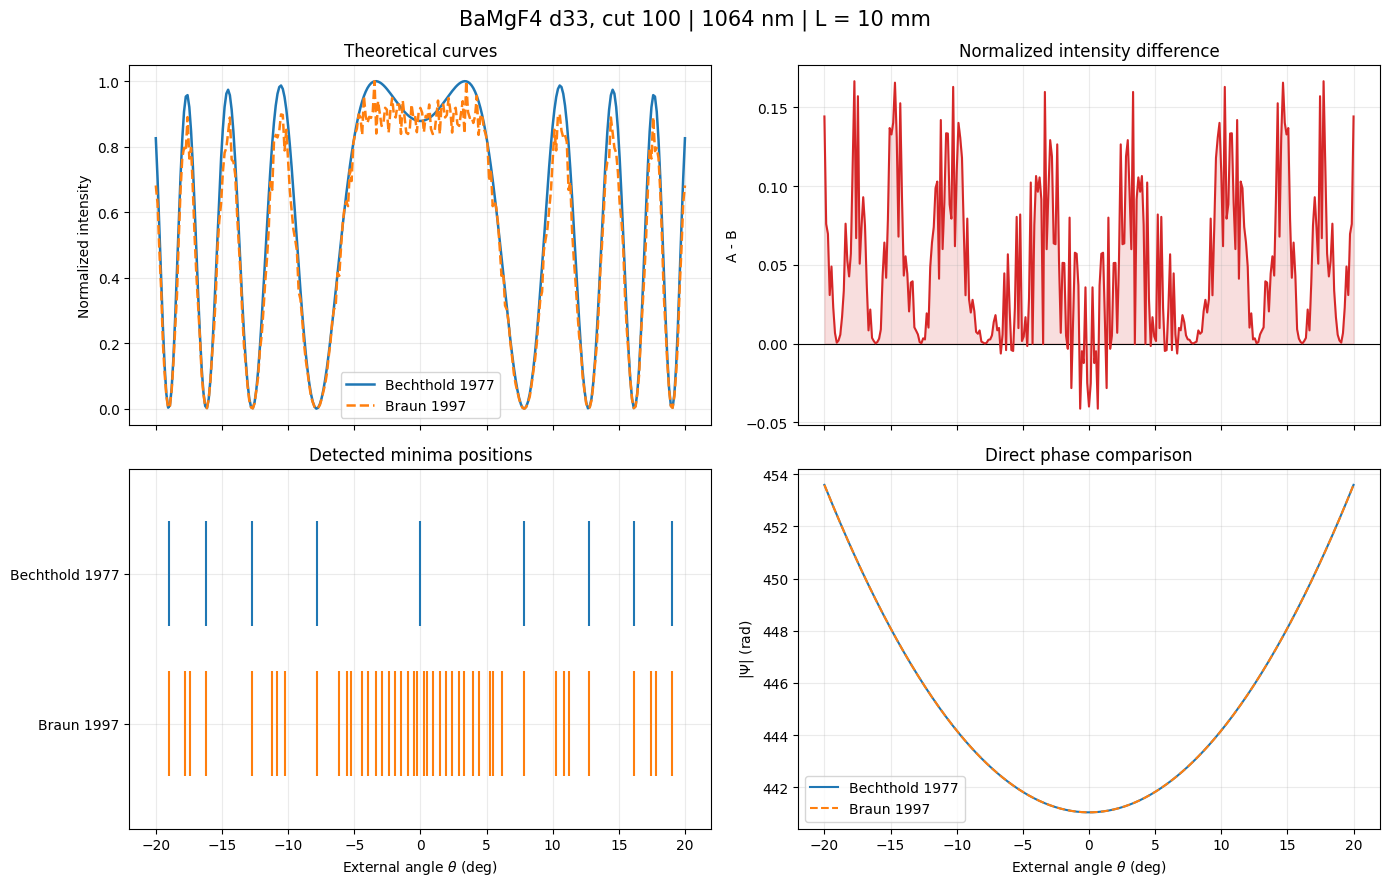

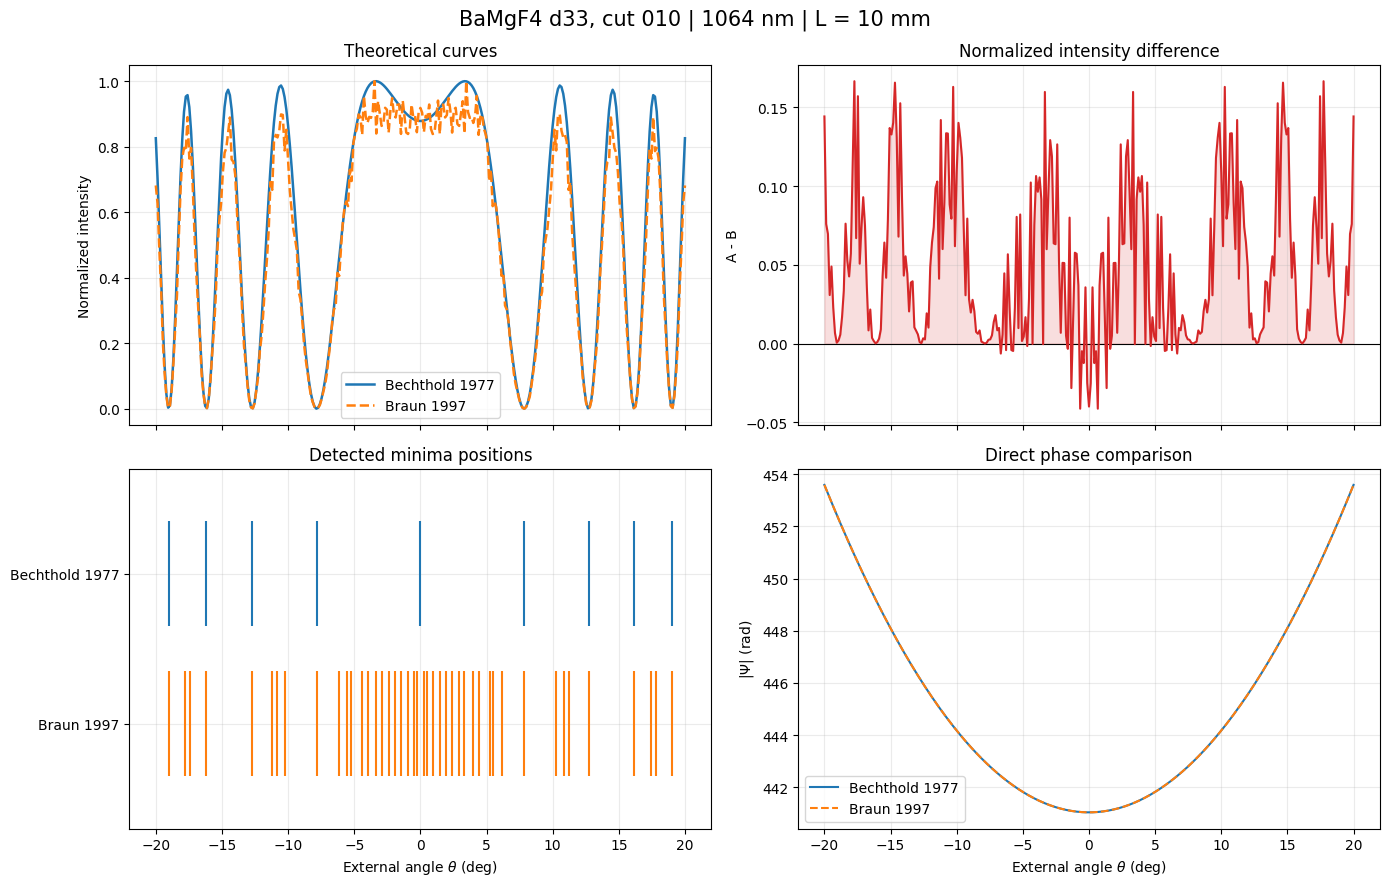

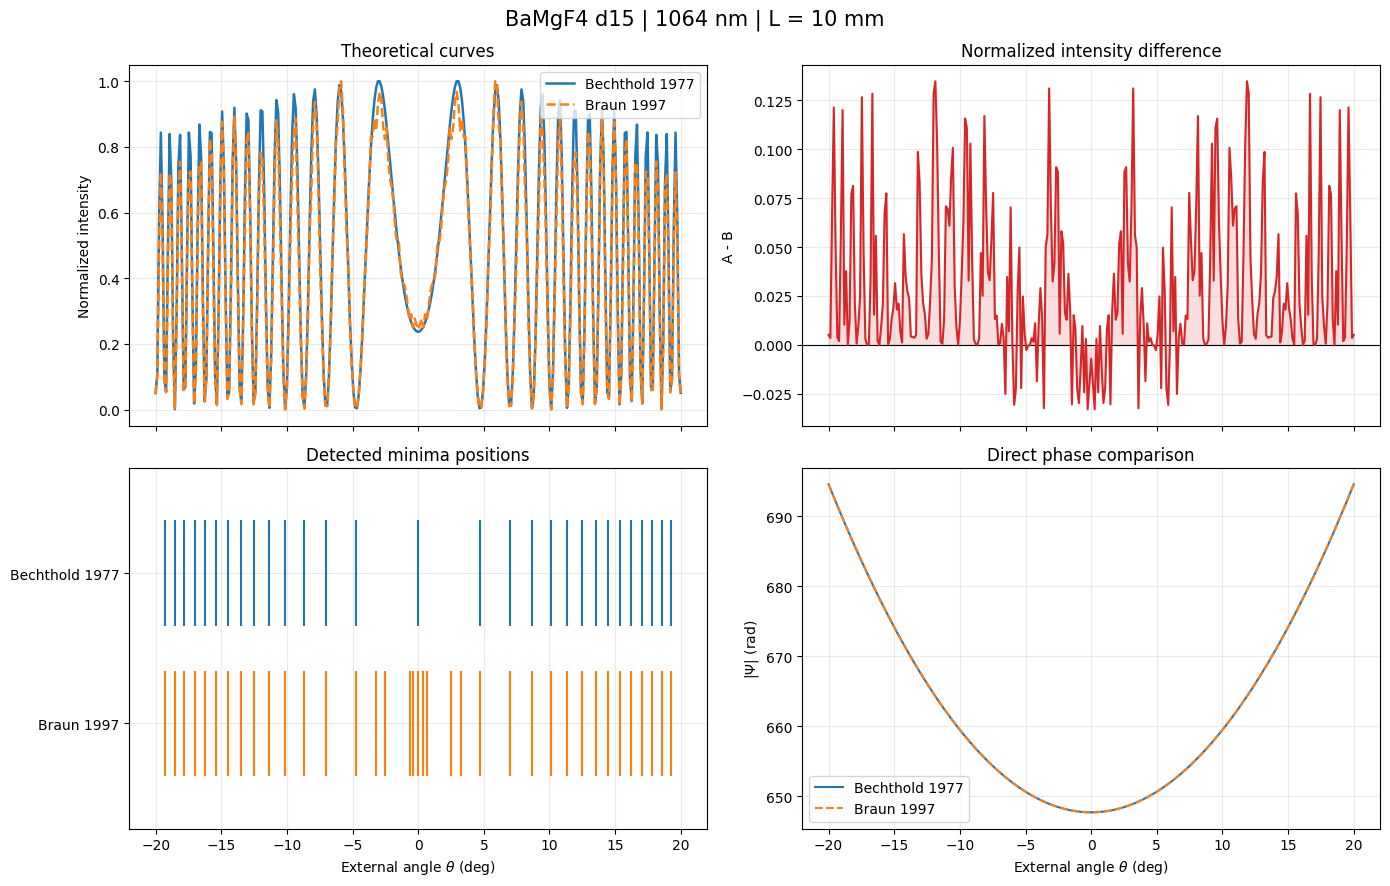

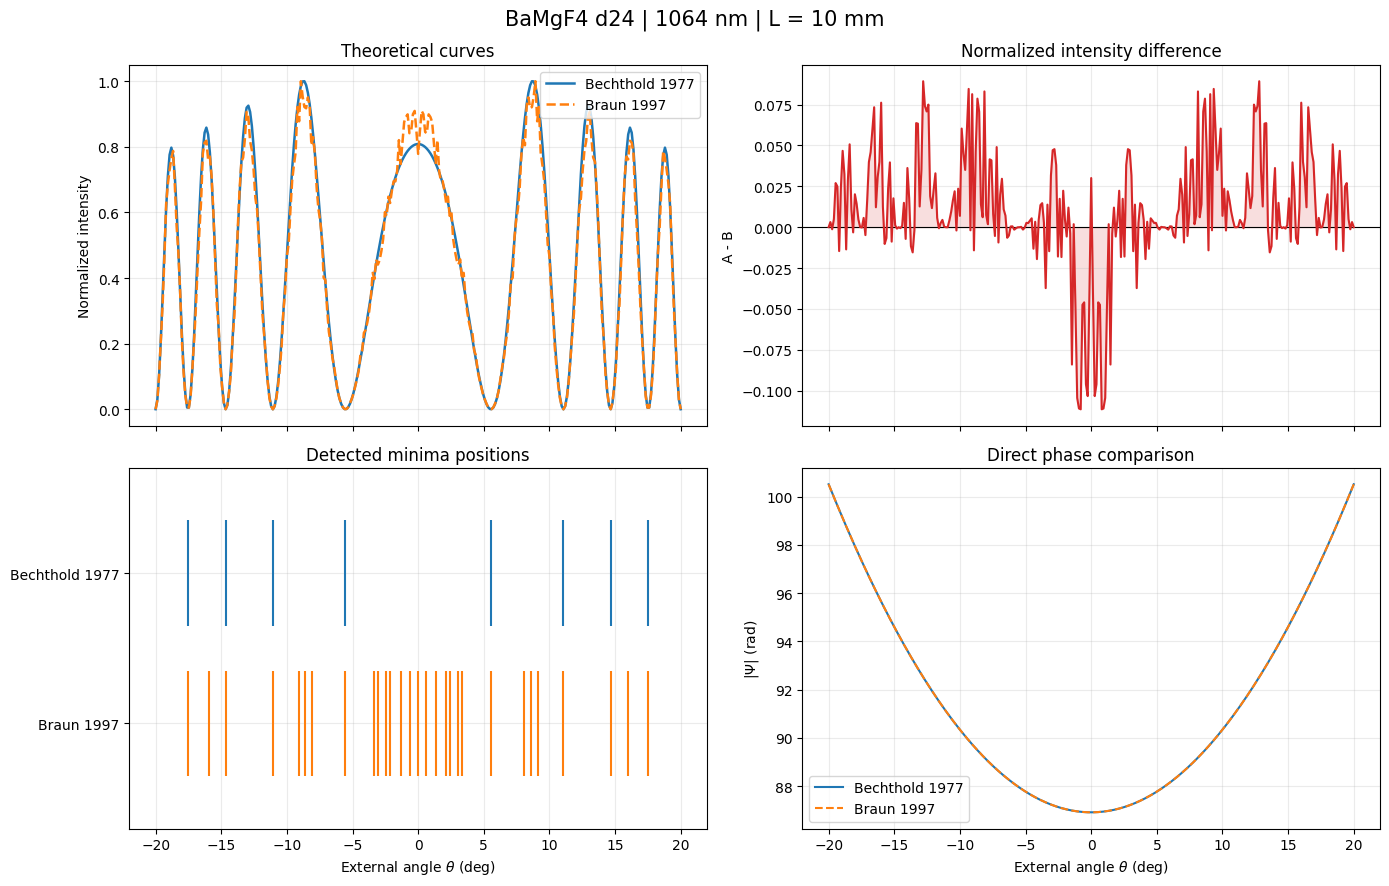

In [27]:
for config_name, comparison in comparison_results.items():
    config = comparison["config"]
    result_a = comparison["result_a"]
    result_b = comparison["result_b"]
    intensity_difference = comparison["intensity_difference"]
    minima_a = comparison["minima_a"]
    minima_b = comparison["minima_b"]

    fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
    ax_curve, ax_difference, ax_minima, ax_phase = axes.ravel()

    ax_curve.plot(theta_deg, result_a["normalized"], lw=1.8, label=result_a["name"])
    ax_curve.plot(
        theta_deg, result_b["normalized"], lw=1.8, ls="--", label=result_b["name"]
    )
    ax_curve.set_ylabel("Normalized intensity")
    ax_curve.set_title("Theoretical curves")
    ax_curve.legend()

    ax_difference.axhline(0.0, color="black", lw=0.8)
    ax_difference.plot(theta_deg, intensity_difference, color="C3", lw=1.5)
    ax_difference.fill_between(
        theta_deg, 0.0, intensity_difference, color="C3", alpha=0.15
    )
    ax_difference.set_ylabel("A - B")
    ax_difference.set_title("Normalized intensity difference")

    ax_minima.eventplot(minima_a, lineoffsets=1.0, linelengths=0.7, colors="C0")
    ax_minima.eventplot(minima_b, lineoffsets=0.0, linelengths=0.7, colors="C1")
    ax_minima.set_yticks([0.0, 1.0], [result_b["name"], result_a["name"]])
    ax_minima.set_ylim(-0.7, 1.7)
    ax_minima.set_title("Detected minima positions")

    if comparison["has_direct_phase_comparison"]:
        ax_phase.plot(theta_deg, comparison["phase_a"], lw=1.5, label=result_a["name"])
        ax_phase.plot(
            theta_deg, comparison["phase_b"], lw=1.5, ls="--", label=result_b["name"]
        )
        ax_phase.set_ylabel(r"$|\Psi|$ (rad)")
        ax_phase.set_title("Direct phase comparison")
        ax_phase.legend()
    else:
        ax_phase.text(
            0.5,
            0.5,
            "Direct phase comparison unavailable\nfor at least one selected model.\n"
            "Use the minima comparison instead.",
            ha="center",
            va="center",
            transform=ax_phase.transAxes,
        )
        ax_phase.set_title("Direct phase comparison")

    for ax in axes.ravel():
        ax.grid(alpha=0.25)
    for ax in axes[-1, :]:
        ax.set_xlabel(r"External angle $\theta$ (deg)")

    fig.suptitle(
        f"BaMgF4 {config['label']} | {settings['wavelength_nm']:g} nm | "
        f"L = {settings['thickness_mm']:g} mm",
        fontsize=15,
    )
    fig.tight_layout()
    plt.show()

## Numerical summary

For Braun, `Psi` is the effective free/bound-wave phase difference returned by the current implementation. Its full transmitted intensity is not reconstructed as a simple `sin^2(Psi)` factor, so the minima-angle comparison should be treated as the primary model-independent phase diagnostic.

The table below summarizes every calculated geometry. Detailed paired-minimum tables remain available as, for example, `minima_tables["d31"]`.

In [28]:
summary_rows = []
minima_tables = {}

for config_name, comparison in comparison_results.items():
    result_a = comparison["result_a"]
    result_b = comparison["result_b"]
    minima_comparison = comparison["minima_comparison"]
    row = {
        "geometry": comparison["config"]["label"],
        "theory_a": result_a["name"],
        "theory_b": result_b["name"],
        "max_abs_intensity_difference": float(
            np.nanmax(np.abs(comparison["intensity_difference"]))
        ),
        "minima_a": len(comparison["minima_a"]),
        "minima_b": len(comparison["minima_b"]),
        "paired_minima": len(minima_comparison),
        "minima_angle_rms_difference_deg": (
            float(np.sqrt(np.mean(minima_comparison["A - B (deg)"] ** 2)))
            if not minima_comparison.empty
            else np.nan
        ),
        "direct_phase_comparison": comparison["has_direct_phase_comparison"],
        "max_abs_phase_difference_rad": np.nan,
    }
    if comparison["has_direct_phase_comparison"]:
        row["max_abs_phase_difference_rad"] = float(
            np.nanmax(np.abs(comparison["phase_a"] - comparison["phase_b"]))
        )
    summary_rows.append(row)
    minima_tables[config_name] = minima_comparison

summary = pd.DataFrame(summary_rows).set_index("geometry")
summary

,theory_a,theory_b,max_abs_intensity_difference,minima_a,minima_b,paired_minima,minima_angle_rms_difference_deg,direct_phase_comparison,max_abs_phase_difference_rad
geometry,,,,,,,,,
d31,Bechthold 1977,Braun 1997,0.075314,14,13,13,3.305186,True,2.622258e-11
d32,Bechthold 1977,Braun 1997,0.164989,40,43,40,1.715154,True,2.637535e-11
"d33, cut 100",Bechthold 1977,Braun 1997,0.166543,9,44,9,12.679642,True,5.684342e-14
"d33, cut 010",Bechthold 1977,Braun 1997,0.166543,9,44,9,12.679642,True,5.684342e-14
d15,Bechthold 1977,Braun 1997,0.134761,29,37,29,4.919160,True,1.318767e-11
d24,Bechthold 1977,Braun 1997,0.111334,8,29,8,11.494590,True,1.313083e-11
